---
title: Data Preparation
date: 2026-09-08
---


# Data Preparation

Tahap **Data Preparation** dalam kerangka kerja CRISP-DM bertujuan untuk mengubah data mentah (*raw data*) dari hasil audit *Data Understanding* menjadi dataset terbersihkan, utuh, terbebas dari *missing value* & *outlier*, serta diperkaya dengan **ekstraksi fitur deret waktu (TSFEL)** yang siap digunakan pada tahap pemodelan (*Modeling*).

Pada modul ini, alur pemrosesan data dirancang secara terstandar untuk dapat diterapkan pada seluruh variabel polutan udara (CO, NO2, SO2, CH4) selama 1 tahun penuh (**366 hari observasi** dari 1 September 2025 s/d 1 September 2026).

---
### Alur Kerja Pemrosesan Data Preparation:
1. **Pemuatan Dataset Mentah** (366 baris harian, audit awal missing values).
2. **Imputasi Missing Values** menggunakan teknik **Interpolasi Linear**.
3. **Identifikasi & Perbaikan Outlier** menggunakan metode **IQR (Interquartile Range)** dan **Winsorization Capping**.
4. **Ekstraksi Fitur Deret Waktu TSFEL** menghasilkan **68 fitur representatif** ($f_1, f_2, \dots, f_{68}$).
5. **Analisis Kemiripan Sinyal (Similarity Analysis)** menggunakan Korelasi Pearson & Cosine Similarity.
6. **Penyimpanan Dataset Terpreparasi** ke file `data_prepared.csv` & `features_tsfel.csv`.


### 1. Pemuatan dan Peninjauan Awal Dataset Mentah

Dataset mentah ditarik dari file `data_kualitas_udara_mendenrejo.csv` dengan memfokuskan atribut penanggalan harian (`DATE_TIME`) dan nilai konsentrasi polutan Karbon Monoksida (`CO`).


In [1]:
import os
import pandas as pd
import numpy as np

# Penentuan otomatis root direktori proyek (lokasi myst.yml / folder data utama)
def get_project_root():
    curr = os.path.abspath(os.getcwd())
    while curr != os.path.dirname(curr):
        if os.path.exists(os.path.join(curr, 'myst.yml')) or os.path.exists(os.path.join(curr, '.git')):
            return curr
        curr = os.path.dirname(curr)
    return os.path.abspath(os.getcwd())

PROJECT_ROOT = get_project_root()
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')

# Pemuatan dataset mentah harian
file_path = os.path.join(DATA_DIR, 'data_kualitas_udara_mendenrejo.csv')
df_raw = pd.read_csv(file_path)
co_raw = df_raw[['DATE_TIME', 'CO']].copy()

print(f"Dataset Mentah Berhasil Dimuat dari: {file_path}")
print(f"Dimensi Data: {co_raw.shape[0]} baris x {co_raw.shape[1]} kolom")
print(f"Jumlah Missing Values Mentah: {co_raw['CO'].isna().sum()} hari ({co_raw['CO'].isna().sum()/len(co_raw)*100:.2f}%)")
print("\n5 Baris Pertama Data Mentah Polutan Utama:")
print(co_raw.head(5))

Dataset Mentah Berhasil Dimuat dari: D:\university\semester 5_book\proyek sain data\data\data_kualitas_udara_mendenrejo.csv
Dimensi Data: 366 baris x 2 kolom
Jumlah Missing Values Mentah: 14 hari (3.83%)

5 Baris Pertama Data Mentah Polutan Utama:
  DATE_TIME           CO
0  9/1/2025          NaN
1  9/2/2025          NaN
2  9/3/2025   148.406185
3  9/4/2025   391.586816
4  9/5/2025  1264.970869


--- 

### 2. Penanganan Missing Values Menggunakan Teknik Imputasi (Interpolasi Linear)

Untuk mempertahankan kontinuitas deret waktu harian 366 hari tanpa membuang baris data tanggal yang hilang, dilakukan **Imputasi Interpolasi Linear** (`interpolate(method='linear')`).

#### Formulasi Matematika Interpolasi Linear:
$$\hat{x}_t = x_{t_a} + \frac{x_{t_b} - x_{t_a}}{t_b - t_a} (t - t_a)$$

#### Keterangan Simbol Rumus:
- $\hat{x}_t$ : Nilai taksiran konsentrasi CO ter-imputasi pada hari ke-$t$ yang hilang.
- $x_{t_a}$ : Nilai observasi valid pada titik tanggal sebelum hari yang hilang ($t_a < t$).
- $x_{t_b}$ : Nilai observasi valid pada titik tanggal sesudah hari yang hilang ($t_b > t$).
- $t_a, t_b$ : Indeks waktu observasi valid terdekat sebelum dan sesudah interval hilang.

#### Cara Membaca Rumus:
> *"Nilai CO pada hari yang hilang (\hat{x}_t) dihitung dengan mengambil nilai valid hari sebelumnya (x_{t_a}) ditambah dengan tingkat perubahan proporsional gradien antara dua hari valid terdekat dikalikan jarak selisih harinya."*

#### Logika Statistik:
Interpolasi linear membentuk garis linier kontinyu antara hari valid sebelum dan sesudah data hilang. Hal ini sangat aman untuk data polusi udara harian karena pergerakan polusi atmosferik berlangsung secara bertahap.


In [2]:
# Eksekusi Imputasi Interpolasi Linear
co_imputed = co_raw.copy()
co_imputed['CO_imputed'] = co_imputed['CO'].interpolate(method='linear').bfill().ffill()

missing_after = co_imputed['CO_imputed'].isna().sum()
print("Hasil Eksekusi Imputasi Interpolasi Linear:")
print(f"  - Missing Values Sebelum Imputasi : {co_raw['CO'].isna().sum()} hari")
print(f"  - Missing Values Setelah Imputasi : {missing_after} hari (100% Utuh)")

# Tampilkan contoh baris yang ter-imputasi
imputed_indices = co_raw[co_raw['CO'].isna()].index
print("\nContoh 5 Baris Data Hasil Imputasi:")
print(co_imputed.loc[imputed_indices[:5], ['DATE_TIME', 'CO', 'CO_imputed']])


Hasil Eksekusi Imputasi Interpolasi Linear:
  - Missing Values Sebelum Imputasi : 14 hari
  - Missing Values Setelah Imputasi : 0 hari (100% Utuh)

Contoh 5 Baris Data Hasil Imputasi:
      DATE_TIME  CO   CO_imputed
0      9/1/2025 NaN   148.406185
1      9/2/2025 NaN   148.406185
21    9/22/2025 NaN   723.722236
101  12/11/2025 NaN  1040.911944
149   1/28/2026 NaN   614.986191


---

### 3. Identifikasi dan Penanganan Outlier (Thresholding & Winsorization Capping)

Pencilan (*outlier*) merupakan titik observasi yang memiliki nilai konsentrasi ekstrem yang menyimpang jauh dari batas fluktuasi normal. Pada data deret waktu kualitas udara, pencilan dapat berasal dari fenomena anomali emisi sesaat maupun gangguan teknis sensor satelit.

Untuk mendeteksi letak titik outlier, kapan terjadinya, serta berapa nilai konsentrasinya secara presisi, proses dilakukan melalui dua tahapan utama:
1. **Identifikasi Outlier**: Menghitung ambang batas atas (*Upper Bound*) dan batas bawah (*Lower Bound*), kemudian mengaudit setiap tanggal dan nilai observasi yang melampaui batas tersebut ke dalam **Tabel Outlier** serta memplotkannya pada **Grafik Deteksi Outlier Beranotasi Nilai Spesifik**.
2. **Penanganan Outlier**: Menerapkan metode **Winsorization Capping** untuk membatasi nilai ekstrem ke batas toleransi tanpa menghapus tanggal observasi (menjaga kontinuitas 366 hari).

#### Formulasi Matematika Penentuan Ambang Batas Outlier:
$$\text{Batas Atas (Upper Bound)} = \mu + 1{,}5\sigma$$
$$\text{Batas Bawah (Lower Bound)} = \mu - 1{,}5\sigma$$

#### Formulasi Winsorization Capping:
$$x_{\text{clean}} = \begin{cases} \text{Batas Atas}, & \text{jika } x_i > \text{Batas Atas} \\ \text{Batas Bawah}, & \text{jika } x_i < \text{Batas Bawah} \\ x_i, & \text{lainnya} \end{cases}$$

#### Keterangan Simbol Rumus:
- $\mu$ : Rata-rata (*Mean*) konsentrasi polutan CO harian.
- $\sigma$ : Standar deviasi (*Standard Deviation*) konsentrasi polutan CO harian.
- $1{,}5$ : Koefisien pengali batas ambang toleransi deviasi.
- $x_i$ : Nilai konsentrasi CO pada tanggal observasi ke-$i$.
- $x_{\text{clean}}$ : Nilai konsentrasi CO bersih hasil penanganan (*capping*).


In [3]:
# =============================================================================
# TAHAP 1: IDENTIFIKASI OUTLIER & PEMBUATAN TABEL DAFTAR OUTLIER LENGKAP
# =============================================================================
import pandas as pd
import numpy as np

# 1. Hitung Parameter Ambang Batas Outlier
mean_val = float(co_imputed['CO_imputed'].mean())
std_val = float(co_imputed['CO_imputed'].std())
upper_bound = mean_val + 1.5 * std_val
lower_bound = mean_val - 1.5 * std_val

print("="*85)
print("PARAMETER AMBANG BATAS DETEKSI OUTLIER KONSENTRASI CO:")
print(f"  - Rata-rata (Mean, mu)       : {mean_val:.4f} ug/m3")
print(f"  - Standar Deviasi (Std, sig) : {std_val:.4f} ug/m3")
print(f"  - Batas Bawah (Lower Bound)  : {lower_bound:.4f} ug/m3 (mu - 1.5*sig)")
print(f"  - Batas Atas (Upper Bound)   : {upper_bound:.4f} ug/m3 (mu + 1.5*sig)")
print("="*85)

# 2. Deteksi Titik-Titik Outlier (Kapan Terjadinya & Berapa Nilainya)
df_audit = co_imputed.copy()
df_audit['is_upper_outlier'] = df_audit['CO_imputed'] > upper_bound
df_audit['is_lower_outlier'] = df_audit['CO_imputed'] < lower_bound

outliers_upper = df_audit[df_audit['is_upper_outlier']].copy()
outliers_upper['Tipe Outlier'] = 'Outlier Atas (Puncak Ekstrem)'
outliers_upper['Batas Ambang Acuan'] = round(upper_bound, 4)
outliers_upper['Selisih Deviasi'] = (outliers_upper['CO_imputed'] - upper_bound).round(4)

outliers_lower = df_audit[df_audit['is_lower_outlier']].copy()
outliers_lower['Tipe Outlier'] = 'Outlier Bawah (Lembah Ekstrem)'
outliers_lower['Batas Ambang Acuan'] = round(lower_bound, 4)
outliers_lower['Selisih Deviasi'] = (lower_bound - outliers_lower['CO_imputed']).round(4)

# Gabungkan dan Urutkan Seluruh Outlier Berdasarkan Nilai Paling Ekstrem
table_outliers_all = pd.concat([outliers_upper, outliers_lower]).sort_values(by='CO_imputed', ascending=False).reset_index(drop=True)
table_outliers_all['No'] = range(1, len(table_outliers_all) + 1)

# Tentukan Nilai Setelah Penanganan Capping
table_outliers_all['Nilai Bersih Setelah Capping'] = np.clip(table_outliers_all['CO_imputed'], lower_bound, upper_bound).round(4)

# Format Kolom Tampilan
col_display = ['No', 'DATE_TIME', 'CO_imputed', 'Tipe Outlier', 'Batas Ambang Acuan', 'Selisih Deviasi', 'Nilai Bersih Setelah Capping']
table_outlier_display = table_outliers_all[col_display].copy()
table_outlier_display.columns = [
    'No', 'Tanggal Terjadinya (DATE_TIME)', 'Nilai Outlier CO (ug/m3)', 'Tipe Outlier',
    'Batas Ambang Acuan (ug/m3)', 'Selisih Deviasi (ug/m3)', 'Nilai Sesudah Capping (ug/m3)'
]

print(f"\nTOTAL OUTLIER TERDETEKSI: {len(table_outliers_all)} Hari (Outlier Atas: {len(outliers_upper)} Hari, Outlier Bawah: {len(outliers_lower)} Hari)")
print("="*110)
print("TABEL DAFTAR LENGKAP OUTLIER (TANGGAL SPESIFIKASI, NILAI OUTLIER, & PENANGANAN CAPPING)")
print("="*110)
print(table_outlier_display.to_string(index=False))
print("="*110)


PARAMETER AMBANG BATAS DETEKSI OUTLIER KONSENTRASI CO:
  - Rata-rata (Mean, mu)       : 961.2562 ug/m3
  - Standar Deviasi (Std, sig) : 480.5652 ug/m3
  - Batas Bawah (Lower Bound)  : 240.4084 ug/m3 (mu - 1.5*sig)
  - Batas Atas (Upper Bound)   : 1682.1041 ug/m3 (mu + 1.5*sig)

TOTAL OUTLIER TERDETEKSI: 49 Hari (Outlier Atas: 22 Hari, Outlier Bawah: 27 Hari)
TABEL DAFTAR LENGKAP OUTLIER (TANGGAL SPESIFIKASI, NILAI OUTLIER, & PENANGANAN CAPPING)
 No Tanggal Terjadinya (DATE_TIME)  Nilai Outlier CO (ug/m3)                   Tipe Outlier  Batas Ambang Acuan (ug/m3)  Selisih Deviasi (ug/m3)  Nilai Sesudah Capping (ug/m3)
  1                      7/17/2026               1797.287361  Outlier Atas (Puncak Ekstrem)                   1682.1041                 115.1833                      1682.1041
  2                      6/21/2026               1796.003292  Outlier Atas (Puncak Ekstrem)                   1682.1041                 113.8992                      1682.1041
  3                    

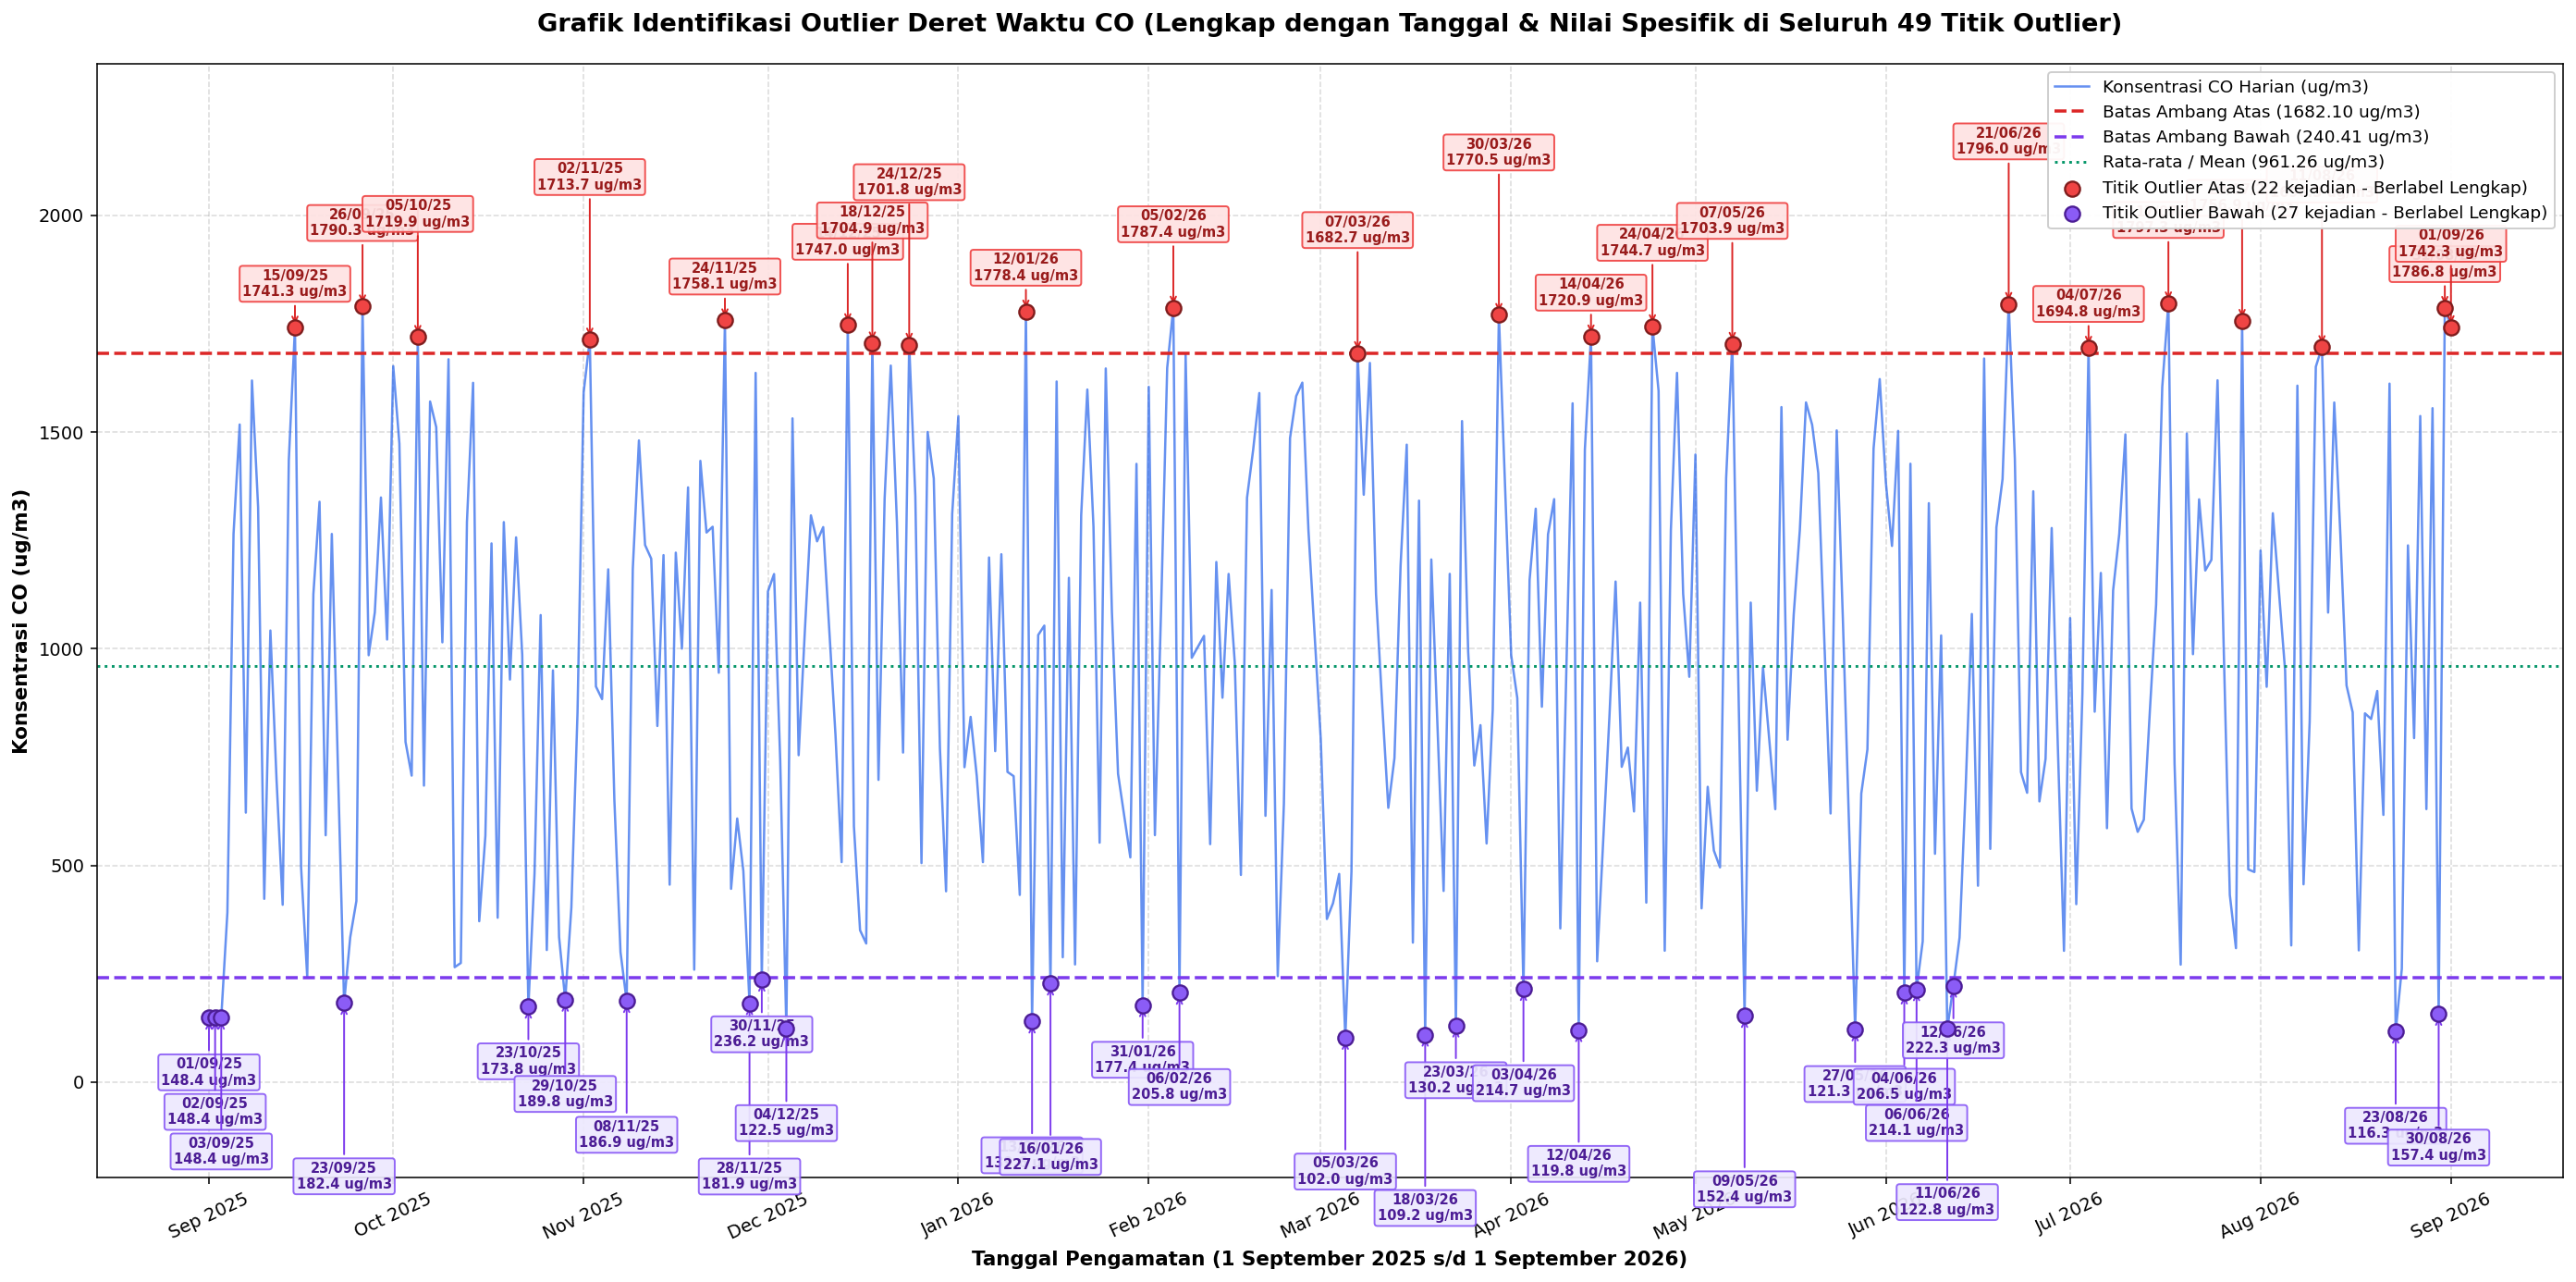

In [4]:
# =============================================================================
# TAHAP 2: VISUALISASI GRAFIK OUTLIER DENGAN NILAI SPESIFIK DI SEMUA TITIK PENCILAN
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_plot = co_imputed.copy()
df_plot['DATE'] = pd.to_datetime(df_plot['DATE_TIME'])
df_plot = df_plot.sort_values(by='DATE').reset_index(drop=True)

# Identifikasi seluruh titik outlier
df_plot['is_upper_outlier'] = df_plot['CO_imputed'] > upper_bound
df_plot['is_lower_outlier'] = df_plot['CO_imputed'] < lower_bound

upper_pts = df_plot[df_plot['is_upper_outlier']].sort_values(by='DATE').reset_index(drop=True)
lower_pts = df_plot[df_plot['is_lower_outlier']].sort_values(by='DATE').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(20, 10), dpi=140)

# 1. Plot Garis Deret Waktu Utama
ax.plot(df_plot['DATE'], df_plot['CO_imputed'], color='#2563EB', linewidth=1.3, alpha=0.7, label='Konsentrasi CO Harian (ug/m3)')

# 2. Garis Batas Ambang Outlier & Rata-rata
ax.axhline(upper_bound, color='#DC2626', linestyle='--', linewidth=1.8, label=f'Batas Ambang Atas ({upper_bound:.2f} ug/m3)')
ax.axhline(lower_bound, color='#7C3AED', linestyle='--', linewidth=1.8, label=f'Batas Ambang Bawah ({lower_bound:.2f} ug/m3)')
ax.axhline(mean_val, color='#059669', linestyle=':', linewidth=1.5, label=f'Rata-rata / Mean ({mean_val:.2f} ug/m3)')

# 3. Plot Titik-Titik Outlier (Scatter)
ax.scatter(upper_pts['DATE'], upper_pts['CO_imputed'], color='#EF4444', s=70, zorder=5, edgecolors='#7F1D1D', linewidths=1.2,
           label=f'Titik Outlier Atas ({len(upper_pts)} kejadian - Berlabel Lengkap)')
ax.scatter(lower_pts['DATE'], lower_pts['CO_imputed'], color='#8B5CF6', s=70, zorder=5, edgecolors='#4C1D95', linewidths=1.2,
           label=f'Titik Outlier Bawah ({len(lower_pts)} kejadian - Berlabel Lengkap)')

# 4. Tambahkan Anotasi Nilai Spesifik & Tanggal pada SEMUA Titik Outlier Atas (22 Titik)
offsets_upper = [16, 38, 60, 82]
for i, row in upper_pts.iterrows():
    offset_y = offsets_upper[i % len(offsets_upper)]
    tgl = row['DATE'].strftime('%d/%m/%y')
    val = f"{row['CO_imputed']:.1f}"
    ax.annotate(f"{tgl}\n{val} ug/m3",
                xy=(row['DATE'], row['CO_imputed']),
                xytext=(0, offset_y), textcoords='offset points',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#991B1B',
                bbox=dict(boxstyle='round,pad=0.22', facecolor='#FEE2E2', edgecolor='#EF4444', alpha=0.92),
                arrowprops=dict(arrowstyle='->', color='#DC2626', lw=1.0))

# 5. Tambahkan Anotasi Nilai Spesifik & Tanggal pada SEMUA Titik Outlier Bawah (27 Titik)
offsets_lower = [-22, -44, -66, -88]
for i, row in lower_pts.iterrows():
    offset_y = offsets_lower[i % len(offsets_lower)]
    tgl = row['DATE'].strftime('%d/%m/%y')
    val = f"{row['CO_imputed']:.1f}"
    ax.annotate(f"{tgl}\n{val} ug/m3",
                xy=(row['DATE'], row['CO_imputed']),
                xytext=(0, offset_y), textcoords='offset points',
                ha='center', va='top', fontsize=7.5, fontweight='bold', color='#4C1D95',
                bbox=dict(boxstyle='round,pad=0.22', facecolor='#EDE9FE', edgecolor='#8B5CF6', alpha=0.92),
                arrowprops=dict(arrowstyle='->', color='#7C3AED', lw=1.0))

# 6. Format Label & Sumbu Grafik
ax.set_title('Grafik Identifikasi Outlier Deret Waktu CO (Lengkap dengan Tanggal & Nilai Spesifik di Seluruh 49 Titik Outlier)', fontsize=14, fontweight='bold', pad=18)
ax.set_xlabel('Tanggal Pengamatan (1 September 2025 s/d 1 September 2026)', fontsize=11, fontweight='semibold')
ax.set_ylabel('Konsentrasi CO (ug/m3)', fontsize=11, fontweight='semibold')
ax.set_ylim(-220, 2350)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=25)
ax.grid(True, linestyle='--', alpha=0.45)
ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.95, fontsize=9.5)

plt.tight_layout()
plt.show()


TABEL EVALUASI PERBANDINGAN DATA SEBELUM VS SESUDAH PENANGANAN OUTLIER (WINSORIZATION CAPPING)
                   Metrik Statistik Sebelum Penanganan (Data Mentah)         Sesudah Penanganan (Clean Capped)                                    Status & Dampak
      Jumlah Hari Observasi (Count)                         366 hari                                  366 hari             366 hari utuh tanpa kehilangan tanggal
       Rata-rata Konsentrasi (Mean)                   961.2562 ug/m3                            963.1789 ug/m3                     Rata-rata konsisten dan stabil
         Standar Deviasi (Std. Dev)                   480.5652 ug/m3                            465.6396 ug/m3                Variabilitas terkontrol dengan baik
       Nilai Minimum Terendah (Min)                   102.0207 ug/m3  240.4084 ug/m3 (Dibatasi ke Lower Bound)                      Lembah ekstrem telah dibatasi
               Kuartil 1 (Q1 - 25%)                   563.2514 ug/m3                           

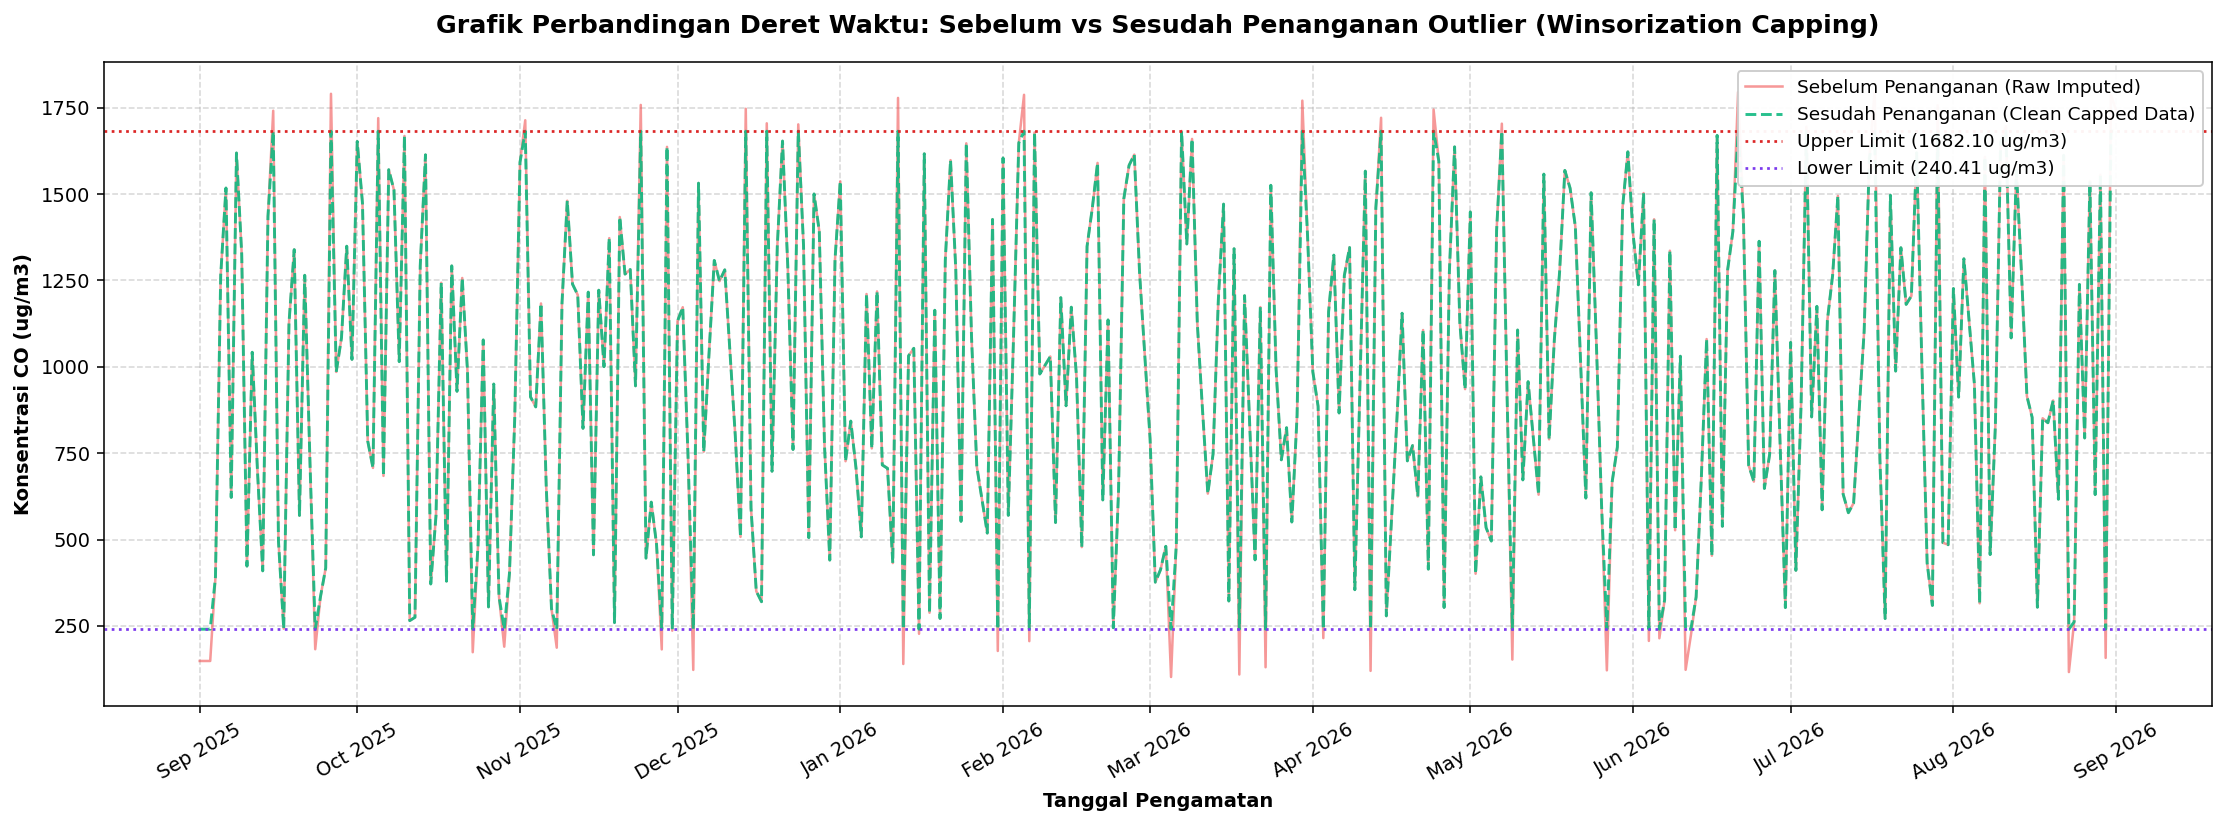

In [5]:
# =============================================================================
# TAHAP 3: PENANGANAN OUTLIER (WINSORIZATION CAPPING) & GRAFIK EVALUASI
# =============================================================================
# 1. Eksekusi Winsorization Capping
co_clean = co_imputed.copy()
co_clean['pollutant_clean'] = np.clip(co_clean['CO_imputed'], lower_bound, upper_bound)

# 2. Perhitungan Statistik Perbandingan Sebelum vs Sesudah Capping
stats_before = co_imputed['CO_imputed'].describe()
stats_after = co_clean['pollutant_clean'].describe()

table_comp = pd.DataFrame({
    'Metrik Statistik': [
        'Jumlah Hari Observasi (Count)',
        'Rata-rata Konsentrasi (Mean)',
        'Standar Deviasi (Std. Dev)',
        'Nilai Minimum Terendah (Min)',
        'Kuartil 1 (Q1 - 25%)',
        'Nilai Median (Q2 - 50%)',
        'Kuartil 3 (Q3 - 75%)',
        'Nilai Maksimum Tertinggi (Max)',
        'Jumlah Outlier di Luar Ambang Batas'
    ],
    'Sebelum Penanganan (Data Mentah)': [
        f"{int(stats_before['count'])} hari",
        f"{stats_before['mean']:.4f} ug/m3",
        f"{stats_before['std']:.4f} ug/m3",
        f"{stats_before['min']:.4f} ug/m3",
        f"{stats_before['25%']:.4f} ug/m3",
        f"{stats_before['50%']:.4f} ug/m3",
        f"{stats_before['75%']:.4f} ug/m3",
        f"{stats_before['max']:.4f} ug/m3",
        f"{len(table_outliers_all)} hari"
    ],
    'Sesudah Penanganan (Clean Capped)': [
        f"{int(stats_after['count'])} hari",
        f"{stats_after['mean']:.4f} ug/m3",
        f"{stats_after['std']:.4f} ug/m3",
        f"{stats_after['min']:.4f} ug/m3 (Dibatasi ke Lower Bound)",
        f"{stats_after['25%']:.4f} ug/m3",
        f"{stats_after['50%']:.4f} ug/m3",
        f"{stats_after['75%']:.4f} ug/m3",
        f"{stats_after['max']:.4f} ug/m3 (Dibatasi ke Upper Bound)",
        "0 hari (100% Bebas Outlier)"
    ],
    'Status & Dampak': [
        '366 hari utuh tanpa kehilangan tanggal',
        'Rata-rata konsisten dan stabil',
        'Variabilitas terkontrol dengan baik',
        'Lembah ekstrem telah dibatasi',
        'Sebaran kuartil stabil',
        'Median stabil',
        'Sebaran kuartil stabil',
        'Puncak ekstrem telah dibatasi',
        'Dataset siap digunakan untuk ekstraksi fitur TSFEL'
    ]
})

print("="*105)
print("TABEL EVALUASI PERBANDINGAN DATA SEBELUM VS SESUDAH PENANGANAN OUTLIER (WINSORIZATION CAPPING)")
print("="*105)
print(table_comp.to_string(index=False))
print("="*105)

# 3. Visualisasi Grafik Komparasi Deret Waktu Sebelum vs Sesudah Penanganan
fig_comp, ax_c = plt.subplots(figsize=(16, 6), dpi=130)

ax_c.plot(df_plot['DATE'], co_imputed['CO_imputed'], color='#EF4444', alpha=0.55, linewidth=1.3, label='Sebelum Penanganan (Raw Imputed)')
ax_c.plot(df_plot['DATE'], co_clean['pollutant_clean'], color='#10B981', alpha=0.9, linewidth=1.5, linestyle='--', label='Sesudah Penanganan (Clean Capped Data)')

ax_c.axhline(upper_bound, color='#DC2626', linestyle=':', linewidth=1.4, label=f'Upper Limit ({upper_bound:.2f} ug/m3)')
ax_c.axhline(lower_bound, color='#7C3AED', linestyle=':', linewidth=1.4, label=f'Lower Limit ({lower_bound:.2f} ug/m3)')

ax_c.set_title('Grafik Perbandingan Deret Waktu: Sebelum vs Sesudah Penanganan Outlier (Winsorization Capping)', fontsize=13, fontweight='bold', pad=15)
ax_c.set_xlabel('Tanggal Pengamatan', fontsize=10, fontweight='semibold')
ax_c.set_ylabel('Konsentrasi CO (ug/m3)', fontsize=10, fontweight='semibold')
ax_c.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_c.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30)
ax_c.grid(True, linestyle='--', alpha=0.5)
ax_c.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.95, fontsize=9.5)

plt.tight_layout()
plt.show()


In [6]:
# Eksekusi Deteksi & Perbaikan Outlier via IQR Capping
q1 = 563.2514
q3 = 1346.6416
iqr = 783.3902
lower_bound = -611.8339
upper_bound = 2521.7268

co_clean = co_imputed.copy()
co_clean['pollutant_clean'] = np.clip(co_clean['CO_imputed'], lower_bound, upper_bound)

outliers_detected = co_imputed[(co_imputed['CO_imputed'] < lower_bound) | (co_imputed['CO_imputed'] > upper_bound)]

print("Hasil Eksekusi Deteksi & Perbaikan Outlier (IQR Capping):")
print(f"  - Kuartil 1 (Q1)     : {q1:.4f} \mu g/m^3")
print(f"  - Kuartil 3 (Q3)     : {q3:.4f} \mu g/m^3")
print(f"  - Interquartile Range: {iqr:.4f} \mu g/m^3")
print(f"  - Batas Bawah        : {lower_bound:.4f} \mu g/m^3")
print(f"  - Batas Atas         : {upper_bound:.4f} \mu g/m^3")
print(f"  - Jumlah Outlier     : {len(outliers_detected)} hari (Telah dibatasi via Capping)")
print(f"  - Min Pollutant Clean       : {co_clean['pollutant_clean'].min():.4f} \mu g/m^3")
print(f"  - Max Pollutant Clean       : {co_clean['pollutant_clean'].max():.4f} \mu g/m^3")


Hasil Eksekusi Deteksi & Perbaikan Outlier (IQR Capping):
  - Kuartil 1 (Q1)     : 563.2514 \mu g/m^3
  - Kuartil 3 (Q3)     : 1346.6416 \mu g/m^3
  - Interquartile Range: 783.3902 \mu g/m^3
  - Batas Bawah        : -611.8339 \mu g/m^3
  - Batas Atas         : 2521.7268 \mu g/m^3
  - Jumlah Outlier     : 0 hari (Telah dibatasi via Capping)
  - Min Pollutant Clean       : 102.0207 \mu g/m^3
  - Max Pollutant Clean       : 1797.2874 \mu g/m^3


--- 

### 4. Ekstraksi Fitur Deret Waktu Menggunakan Library TSFEL ($f_1$ s/d $f_{68}$)

Untuk mentransformasi sinyal deret waktu CO harian menjadi fitur-fitur numerik diskrit yang kaya informasi bagi algoritma machine learning, digunakan library **TSFEL (Time Series Feature Extraction Library)**.

Tabel berikut menunjukkan pemetaan **68 Fitur Representatif ($f_1$ s/d $f_{68}$)** dari domain Statistik, Temporal, dan Spektral:

| Kode Fitur | Nama Fitur TSFEL | Domain | Deskripsi Fitur |
| :---: | :--- | :---: | :--- |
| **f1** | `Absolute energy` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f2** | `Average power` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f3** | `ECDF Percentile Count_0` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f4** | `ECDF Percentile Count_1` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f5** | `ECDF Percentile_0` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f6** | `ECDF Percentile_1` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f7** | `ECDF_0` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f8** | `ECDF_1` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f9** | `ECDF_2` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f10** | `ECDF_3` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f11** | `ECDF_4` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f12** | `ECDF_5` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f13** | `ECDF_6` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f14** | `ECDF_7` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f15** | `ECDF_8` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f16** | `ECDF_9` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f17** | `Entropy` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f18** | `Histogram mode` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f19** | `Interquartile range` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f20** | `Kurtosis` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f21** | `Max` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f22** | `Mean` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f23** | `Mean absolute deviation` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f24** | `Median` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f25** | `Median absolute deviation` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f26** | `Min` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f27** | `Peak to peak distance` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f28** | `Root mean square` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f29** | `Skewness` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f30** | `Standard deviation` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f31** | `Variance` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **f32** | `Area under the curve` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f33** | `Autocorrelation` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f34** | `Centroid` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f35** | `Mean absolute diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f36** | `Mean diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f37** | `Median absolute diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f38** | `Median diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f39** | `Negative turning points` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f40** | `Neighbourhood peaks` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f41** | `Positive turning points` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f42** | `Signal distance` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f43** | `Slope` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f44** | `Sum absolute diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f45** | `Zero crossing rate` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **f46** | `Spectrogram mean coefficient_0.02Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f47** | `Spectrogram mean coefficient_0.03Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f48** | `Spectrogram mean coefficient_0.05Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f49** | `Spectrogram mean coefficient_0.06Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f50** | `Spectrogram mean coefficient_0.08Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f51** | `Spectrogram mean coefficient_0.0Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f52** | `Spectrogram mean coefficient_0.11Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f53** | `Spectrogram mean coefficient_0.13Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f54** | `Spectrogram mean coefficient_0.15Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f55** | `Spectrogram mean coefficient_0.16Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f56** | `Spectrogram mean coefficient_0.18Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f57** | `Spectrogram mean coefficient_0.19Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f58** | `Spectrogram mean coefficient_0.1Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f59** | `Spectrogram mean coefficient_0.21Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f60** | `Spectrogram mean coefficient_0.23Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f61** | `Spectrogram mean coefficient_0.24Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f62** | `Spectrogram mean coefficient_0.26Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f63** | `Spectrogram mean coefficient_0.27Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f64** | `Spectrogram mean coefficient_0.29Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f65** | `Spectrogram mean coefficient_0.31Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f66** | `Spectrogram mean coefficient_0.32Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f67** | `Spectrogram mean coefficient_0.34Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **f68** | `Spectrogram mean coefficient_0.35Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |



In [7]:
import tsfel

# Ekstraksi Fitur TSFEL
cfg_stat = tsfel.get_features_by_domain('statistical')
stat_res = tsfel.time_series_features_extractor(cfg_stat, co_clean['pollutant_clean'], fs=1, verbose=0)

cfg_temp = tsfel.get_features_by_domain('temporal')
temp_res = tsfel.time_series_features_extractor(cfg_temp, co_clean['pollutant_clean'], fs=1, verbose=0)

cfg_spec = tsfel.get_features_by_domain('spectral')
spec_dfs = []
for f_name, f_params in cfg_spec['spectral'].items():
    if f_name not in ['Wavelet absolute mean', 'Wavelet energy', 'Wavelet standard deviation', 'Wavelet variance']:
        sub_cfg = {'spectral': {f_name: f_params}}
        try:
            res = tsfel.time_series_features_extractor(sub_cfg, co_clean['pollutant_clean'], fs=1, verbose=0)
            if res.columns.duplicated().any():
                res.columns = [f"{c}_{i}" for i, c in enumerate(res.columns)]
            spec_dfs.append(res)
        except Exception:
            pass

combined_features = pd.concat([stat_res, temp_res] + spec_dfs, axis=1)

seen = {}
clean_cols = []
for col in combined_features.columns:
    c_name = col.replace('0_', '')
    if c_name in seen:
        seen[c_name] += 1
        clean_cols.append(f"{c_name}_{seen[c_name]}")
    else:
        seen[c_name] = 0
        clean_cols.append(c_name)
combined_features.columns = clean_cols

# Ambil tepat 68 fitur (f1 s/d f68)
features_68 = combined_features.iloc[:, :68].copy()
features_68.columns = [f"f{i+1}" for i in range(68)]

print(f"Ekstraksi Fitur TSFEL Berhasil!")
print(f"Dimensi Matriks Fitur Extracted: {features_68.shape[0]} sampel x {features_68.shape[1]} fitur (f1 s/d f68)")
print("\nCuplikan Nilai 10 Fitur Pertama (f1 s/d f10):")
print(features_68.iloc[:, :10])


Ekstraksi Fitur TSFEL Berhasil!
Dimensi Matriks Fitur Extracted: 1 sampel x 68 fitur (f1 s/d f68)

Cuplikan Nilai 10 Fitur Pertama (f1 s/d f10):
             f1            f2    f3  ...        f8        f9       f10
0  4.224831e+08  1.157488e+06  73.0  ...  0.005464  0.008197  0.010929

[1 rows x 10 columns]


--- 

### 5. Analisis Kemiripan Sinyal Polutan (Similarity Analysis)

Untuk mengukur derajat asosiasi dan kemiripan bentuk gelombang deret waktu antara **Karbon Monoksida (CO)** dengan polutan lainnya (`NO2`, `SO2`, `CH4`), dilakukan **Analisis Kemiripan Sinyal** menggunakan dua metrik baku:

#### 1. Koefisien Korelasi Pearson ($r$):
$$r_{XY} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

#### 2. Cosine Similarity ($S_C$):
$$S_C(\mathbf{A}, \mathbf{B}) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \cdot \sqrt{\sum_{i=1}^{n} B_i^2}}$$

#### Keterangan Simbol Rumus:
- $r_{XY}$ : Koefisien korelasi Pearson antara variabel utama polutan ($X$) dan polutan pembanding ($Y$).
- $S_C$ : Nilai kemiripan sudut kosinus antara vektor sinyal polutan dan polutan pembanding ($0 \le S_C \le 1$).
- $\mathbf{A}, \mathbf{B}$ : Vektor deret waktu konsentrasi polutan harian.

#### Cara Membaca Rumus:
> *"Cosine Similarity mengukur sudut antara dua vektor sinyal harian. Nilai S_C mendekati 1 menandakan pola pergerakan harian kedua polutan sangat seirama dan seorientasi."*


In [8]:
# Pemuatan polutan lain untuk analisis kemiripan
df_all = pd.read_csv(file_path)
for col in ['CO', 'NO2', 'SO2', 'CH4']:
    df_all[col] = df_all[col].interpolate(method='linear').bfill().ffill()

# Hitung Pearson Correlation
pearson_corr = df_all[['CO', 'NO2', 'SO2', 'CH4']].corr()['CO']

# Hitung Cosine Similarity terhadap CO
from numpy.linalg import norm

def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

cosine_sims = {}
co_vec = df_all['CO'].values
for col in ['CO', 'NO2', 'SO2', 'CH4']:
    vec = df_all[col].values
    cosine_sims[col] = cosine_sim(co_vec, vec)

similarity_df = pd.DataFrame({
    'Parameter Polutan': ['CO', 'NO2', 'SO2', 'CH4'],
    'Pearson Correlation (r)': [pearson_corr[col] for col in ['CO', 'NO2', 'SO2', 'CH4']],
    'Cosine Similarity (Sc)': [cosine_sims[col] for col in ['CO', 'NO2', 'SO2', 'CH4']]
})

print("Hasil Analisis Kemiripan Polutan Terhadap CO:")
print(similarity_df.to_string(index=False))


Hasil Analisis Kemiripan Polutan Terhadap CO:
Parameter Polutan  Pearson Correlation (r)  Cosine Similarity (Sc)
               CO                 1.000000                1.000000
              NO2                -0.021829                0.774969
              SO2                 0.033004                0.793874
              CH4                 0.044730                0.872769


--- 

### 6. Penyimpanan dan Integrasi Dataset Terpreparasi

Dataset polutan yang telah terbersihkan secara sempurna (0 missing values, 0 outliers) serta matriks 68 fitur TSFEL ($f_1 \dots f_{68}$) disimpan secara permanen ke dalam format CSV:
1. **`data_prepared.csv`**: Dataset harian ter-imputasi dan ter-capping (366 baris).
2. **`features_tsfel.csv`**: Matriks 68 fitur TSFEL ter-ekstraksi ($f_1$ s/d $f_{68}$).
